In [19]:
import numpy as np
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
import sklearn
from sklearn import datasets

from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score

In [3]:
# берем данные
train_pd = pd.read_csv("train.csv")
test_pd = pd.read_csv("test.csv")

In [4]:
print(train_pd.shape)
print(test_pd.shape)

train_pd.head()

(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
# PREPROCESSING THE DATA
# Показывает что сделать с каждым столбцом

# 0 - удалить
# 1 - не менять
# 2 - отделить по классам
to_do_column = [0, # id
                2, # MSSubClass           
                2, # MSZoning             
                1, # LotFrontage          
                1, # LotArea              
                2, # Street               
                2, # Alley                
                2, # LotShape             
                2, # LandContour          
                2, # Utilities            
                2, # LotConfig            
                2, # LandSlope           
                2, # Neighborhood
                2, # Condition1           
                2, # Condition2
                2, # BldgType
                2, # HouseStyle
                1, # OverallQual
                1, #OverallCond
                1, #YearBuilt
                1, #YearRemodAdd
                2, #RoofStyle
                2, #RoofMatl
                2, #Exterior1st
                2, #Exterior2nd
                2, #MasVnrType
                1, #MasVnrArea
                2, #ExterQual
                2, #ExterCond
                2, #Foundation
                2, #BsmtQual
                2, #BsmtCond
                2, #BsmtExposure
                2, #BsmtFinType1
                1, #BsmtFinSF1
                2, #BsmtFinType2
                1, #BsmtFinSF2
                1, #BsmtUnfSF
                1, #TotalBsmtSF
                2, #Heating
                2, #HeatingQC
                2, #CentralAir
                2, #Electrical
                1, #1stFlrSF
                1, #2ndFlrSF
                1, #LowQualFinSF
                1, #GrLivArea
                1, #BsmtFullBath
                1, #BsmtHalfBath
                1, #FullBath
                1, #HalfBath
                1, #BedroomAbvGr
                1, #KitchenAbvGr
                2, #KitchenQual
                1, #TotRmsAbvGrd
                2, #Functional
                1, #Fireplaces
                2, #FireplaceQu
                2, #GarageType
                1, #GarageYrBlt
                2, #GarageFinish
                1, #GarageCars
                1, #GarageArea
                2, #GarageQual
                2, #GarageCond
                2, #PavedDrive
                1, #WoodDeckSF
                1, #OpenPorchSF
                1, #EnclosedPorch
                1, #3SsnPorch
                1, #ScreenPorch
                1, #PoolArea
                2, #PoolQC
                2, #Fence
                2, #MiscFeature
                1, #MiscVal
                2, #MoSold
                1, #YrSold
                2, #SaleType
                2,] #SaleCondition

np_to_do_column = np.array(to_do_column)

print(np_to_do_column.shape)
print(np_to_do_column)

(80,)
[0 2 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 2 2 2 2 1 2 2 2 2 2 2 2 1 2 1
 1 1 2 2 2 2 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 2 1 2 1 1 2 2 2 1 1 1 1 1 1 2 2
 2 1 2 1 2 2]


In [8]:
# Проверка на наличие Null/NaN
for col in train_pd.columns:
        missing_number = train_pd[col].isnull().sum()
        data_type = train_pd[col].dtype
        print(f"{col:<20} : {missing_number:<7} : {data_type}")

Id                   : 0       : int64
MSSubClass           : 0       : int64
MSZoning             : 0       : object
LotFrontage          : 259     : float64
LotArea              : 0       : int64
Street               : 0       : object
Alley                : 1369    : object
LotShape             : 0       : object
LandContour          : 0       : object
Utilities            : 0       : object
LotConfig            : 0       : object
LandSlope            : 0       : object
Neighborhood         : 0       : object
Condition1           : 0       : object
Condition2           : 0       : object
BldgType             : 0       : object
HouseStyle           : 0       : object
OverallQual          : 0       : int64
OverallCond          : 0       : int64
YearBuilt            : 0       : int64
YearRemodAdd         : 0       : int64
RoofStyle            : 0       : object
RoofMatl             : 0       : object
Exterior1st          : 0       : object
Exterior2nd          : 0       : object
MasVnr

In [9]:
# Показывает число объектов, показывает уникальный объекты, в том числа NaN
col = "PoolQC"
print(train_pd[col])
print("\nUnique data classes:", train_pd[col].unique())

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
1455    NaN
1456    NaN
1457    NaN
1458    NaN
1459    NaN
Name: PoolQC, Length: 1460, dtype: object

Unique data classes: [nan 'Ex' 'Fa' 'Gd']


In [10]:
# класс обрботки данных
class process_class():
    def __init__(self):
        self.counter_numeric = 0
        self.counter_category = 0
    
    def precessing(self, pandas_data, how_to_process):
        """
        input
        how_to_process - numpy array with proccessing labels [0, 1, 2]
        pandas_data - pandas array train/test array for data processing. Only features with no target column
     
        return:
        np_data_concatenate_numeric - numereic data array after processing
        np_data_concatenate_category - category data array after processing
        header - numpy array for new headers
        """
        header = np.array([])
        np_data_concatenate_numeric = np.zeros((pandas_data.shape[0], 1))
        np_data_concatenate_category = np.zeros((pandas_data.shape[0], 1))
    
        counter_numeric = 0
        counter_category = 0
        
        for col, i in zip(pandas_data.columns, range(how_to_process.shape[0])):
            print(f"i = {i}")
            if (how_to_process[i] == 0):
                # удаляем столбец. Он не нужен. А лучше сказать по другому - мы его не будет вставлять в новый numpy array
                print(f"Column name: {col}")
                print(f"PROCESS TYPE - {how_to_process[i]}")
                print("Column not included \n")        
                continue
        
            elif (how_to_process[i] == 1):
                # копируем из pandas и вставляем в numpy array
                print(f"Column name: {col}")
                print(f"PROCESS TYPE - {how_to_process[i]}")
                counter_numeric += 1 # для проверки
                
                np_add = pandas_data[col].fillna(0).to_numpy()[:, None] # превращаем NaN в нули
                np_data_concatenate_numeric = np.concatenate((np_data_concatenate_numeric, np_add), axis = 1)
                nan_sum = np.isnan(np_add).sum()
                null_num = pandas_data[col].isnull().sum()
                print(f"Null num: {null_num}") # для проверки
                print(f"NaN  num: {nan_sum} \n") # для проверки. Если показывает 0 - все верно
        
                # добавляем названия в header
                header = np.append(header, col)
        
            elif (how_to_process[i] == 2):
                print(f"Column name: {col}")
                print(f"PROCESS TYPE - {how_to_process[i]}")
        
                null_num = pandas_data[col].isnull().sum()
                print(f"Null num: {null_num}") # для проверки
                unique_data_column = pandas_data[col].unique()
                print("Unique data types", unique_data_column.shape[0])
                
                pandas_data[col] = pandas_data[col].fillna("None") # убираем NULL
                null_num = pandas_data[col].isnull().sum()
                print(f"Null num after changed: {null_num}") # для проверки 
                unique_data_column = pandas_data[col].unique()
                print("Unique data types after changed", unique_data_column.shape[0]) # для проверки 
        
                counter_category += unique_data_column.shape[0] # для проверки
                
                # добавляем в наш массив
                np_add = np.zeros((pandas_data.shape[0], unique_data_column.shape[0])) # превращаем NaN в нули
                print("shape", np_add.shape)
                
                for i_new in range(pandas_data.shape[0]):
                    for j_new in range(unique_data_column.shape[0]):
                        if (pandas_data.loc[i_new, col] == unique_data_column[j_new]):
                            np_add[i_new, j_new] = 1 # этот элемент есть
                        else:
                            continue # этого элемента нет - обнуляем
        
                np_data_concatenate_category = np.concatenate((np_data_concatenate_category, np_add), axis = 1)
        
                # добавляем названия в header
                for i in range(unique_data_column.shape[0]):
                    head = str(unique_data_column[i]) + "_" + str(col)
                    header = np.append(header, head)
        
                print("\n")
        
        np_data_concatenate_numeric = np_data_concatenate_numeric[:, :-1] # убираем первый пустой столбец, который добавили в самом начале
        np_data_concatenate_category = np_data_concatenate_category[:, :-1] 

        self.counter_numeric = counter_numeric
        self.counter_category = counter_category
        
        return np_data_concatenate_numeric, np_data_concatenate_category, header

    def concate_display(self, np_data_concatenate_numeric, np_data_concatenate_category, header):
        """
        concatenates numeric and category arrays  
        prints the data after
        """
        np_data_concatenate = np.concatenate((np_data_concatenate_numeric, np_data_concatenate_category), axis = 1)
        
        print("Численные признаки      =", np_data_concatenate_numeric.shape[1], " == ", self.counter_numeric)
        print("Категориальные признаки =", np_data_concatenate_category.shape[1], " == ", self.counter_category)
        print("Размер header           =", header.shape[0])
        print("Количество в header прав=", self.counter_numeric + self.counter_category == header.shape[0])
        print("Размер данных матрицы   =", np_data_concatenate.shape)
        print("Есть ли пропуски        =", np.isnan(np_data_concatenate).any())

        return np_data_concatenate

In [11]:
# обработка данных 
PROC = process_class()
numeric_train, category_train, header_train = PROC.precessing(train_pd, np_to_do_column)
np_data_concatenate = PROC.concate_display(numeric_train, category_train, header_train)

i = 0
Column name: Id
PROCESS TYPE - 0
Column not included 

i = 1
Column name: MSSubClass
PROCESS TYPE - 2
Null num: 0
Unique data types 15
Null num after changed: 0
Unique data types after changed 15
shape (1460, 15)


i = 2
Column name: MSZoning
PROCESS TYPE - 2
Null num: 0
Unique data types 5
Null num after changed: 0
Unique data types after changed 5
shape (1460, 5)


i = 3
Column name: LotFrontage
PROCESS TYPE - 1
Null num: 259
NaN  num: 0 

i = 4
Column name: LotArea
PROCESS TYPE - 1
Null num: 0
NaN  num: 0 

i = 5
Column name: Street
PROCESS TYPE - 2
Null num: 0
Unique data types 2
Null num after changed: 0
Unique data types after changed 2
shape (1460, 2)


i = 6
Column name: Alley
PROCESS TYPE - 2
Null num: 1369
Unique data types 3
Null num after changed: 0
Unique data types after changed 3
shape (1460, 3)


i = 7
Column name: LotShape
PROCESS TYPE - 2
Null num: 0
Unique data types 4
Null num after changed: 0
Unique data types after changed 4
shape (1460, 4)


i = 8
Column na

In [23]:
# для train и validation
x_data = np.copy(np_data_concatenate) 
y_data = train_pd["SalePrice"]

x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x_data, y_data, test_size = 0.2)

In [24]:
# делаем нормировку
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
# Берем LinReg с L2 регуляризацией и CV
lasso = LassoCV(max_iter=50000, cv=5, random_state=42)
lasso.fit(x_train, y_train)
best_alpha = lasso.alpha_
print(f"Лучшая alpha: {best_alpha}")

# Предсказания
y_pred_train = lasso.predict(x_train)
y_pred_test = lasso.predict(x_test)

# Оценка
print(f"Train R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²: {r2_score(y_test, y_pred_test):.4f}")

Лучшая alpha: 1195.6148645392018
Train R²: 0.9129
Test  R²: 0.9017


Здесь будем решать задачу методом RandomForest

In [26]:
import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score, mean_squared_log_error

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [27]:
#preparing pipeling for the RandomForest
Pipeline = sklearn.pipeline.Pipeline
RandomForest = sklearn.ensemble.RandomForestRegressor

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("forest", RandomForest(random_state=42))
])

In [28]:
#Grid for RandomForest
param_grid = {
    'forest__n_estimators': [300, 500, 1000, 2000],
    'forest__max_depth': [3, 5, 7, 10, None],
    'forest__min_samples_split': [2, 5, 10, 20, 50],
    'forest__min_samples_leaf': [2, 3, 5, 10, 20],
    'forest__max_features': ['sqrt', 0.1, 0.2, 0.3, 0.4], 
}

In [29]:
%%time

random_search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter = 80, cv = 5, scoring='neg_mean_squared_log_error', verbose=1, n_jobs=-1)
random_search.fit(x_train, y_train)

print(f"Best params for GridSearch: {random_search.best_params_}")
print(f"Best score for GridSearch: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
CPU times: total: 328 ms
Wall time: 9.16 s


KeyboardInterrupt: 

In [ ]:
y_predicted_forest = random_search.predict(x_train)
print("R2", r2_score(y_train, y_predicted_forest))
print("LMSE", mean_squared_log_error(y_train, y_predicted_forest))

In [31]:
# записываем лучшие данные для дерева
def write_txt(name, array_best_param, best_score):
    """
    writing parameters in new txt file
    """
    name_txt = name + ".txt"
    with open(name, 'w') as f:
        f.write(f"ROC AUC score {best_score:.4f}\n")
        f.write("BEST PARAM INFO\n")
        for key in array_best_param.keys():
            f.write(f"{key:<30} | {array_best_param[key]}\n")   

write_txt("randomsearch_1", random_search.best_params_, random_search.best_score_)

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

In [32]:
# лучшие параметроы после RandomSearchCV
best_params = random_search.best_params_

best_RandomForest = RandomForest(
    n_estimators=best_params['forest__n_estimators'],
    max_depth=best_params['forest__max_depth'],
    min_samples_split=best_params['forest__min_samples_split'],
    min_samples_leaf=best_params['forest__min_samples_leaf'],
    max_features=best_params['forest__max_features']
)

# Обучаемся на всей выборке
best_RandomForest.fit(x_train, y_train)

#predict
y_predicted_valid = best_RandomForest.predict(x_valid)

#score 
print("R2", r2_score(y_valid, y_predicted_valid))
print("LMSE", mean_squared_log_error(y_valid, y_predicted_valid))

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

Train True  (1168,)
Train Pred  (1168,)
Validation True  (292,)
Validation Pred  (292,)


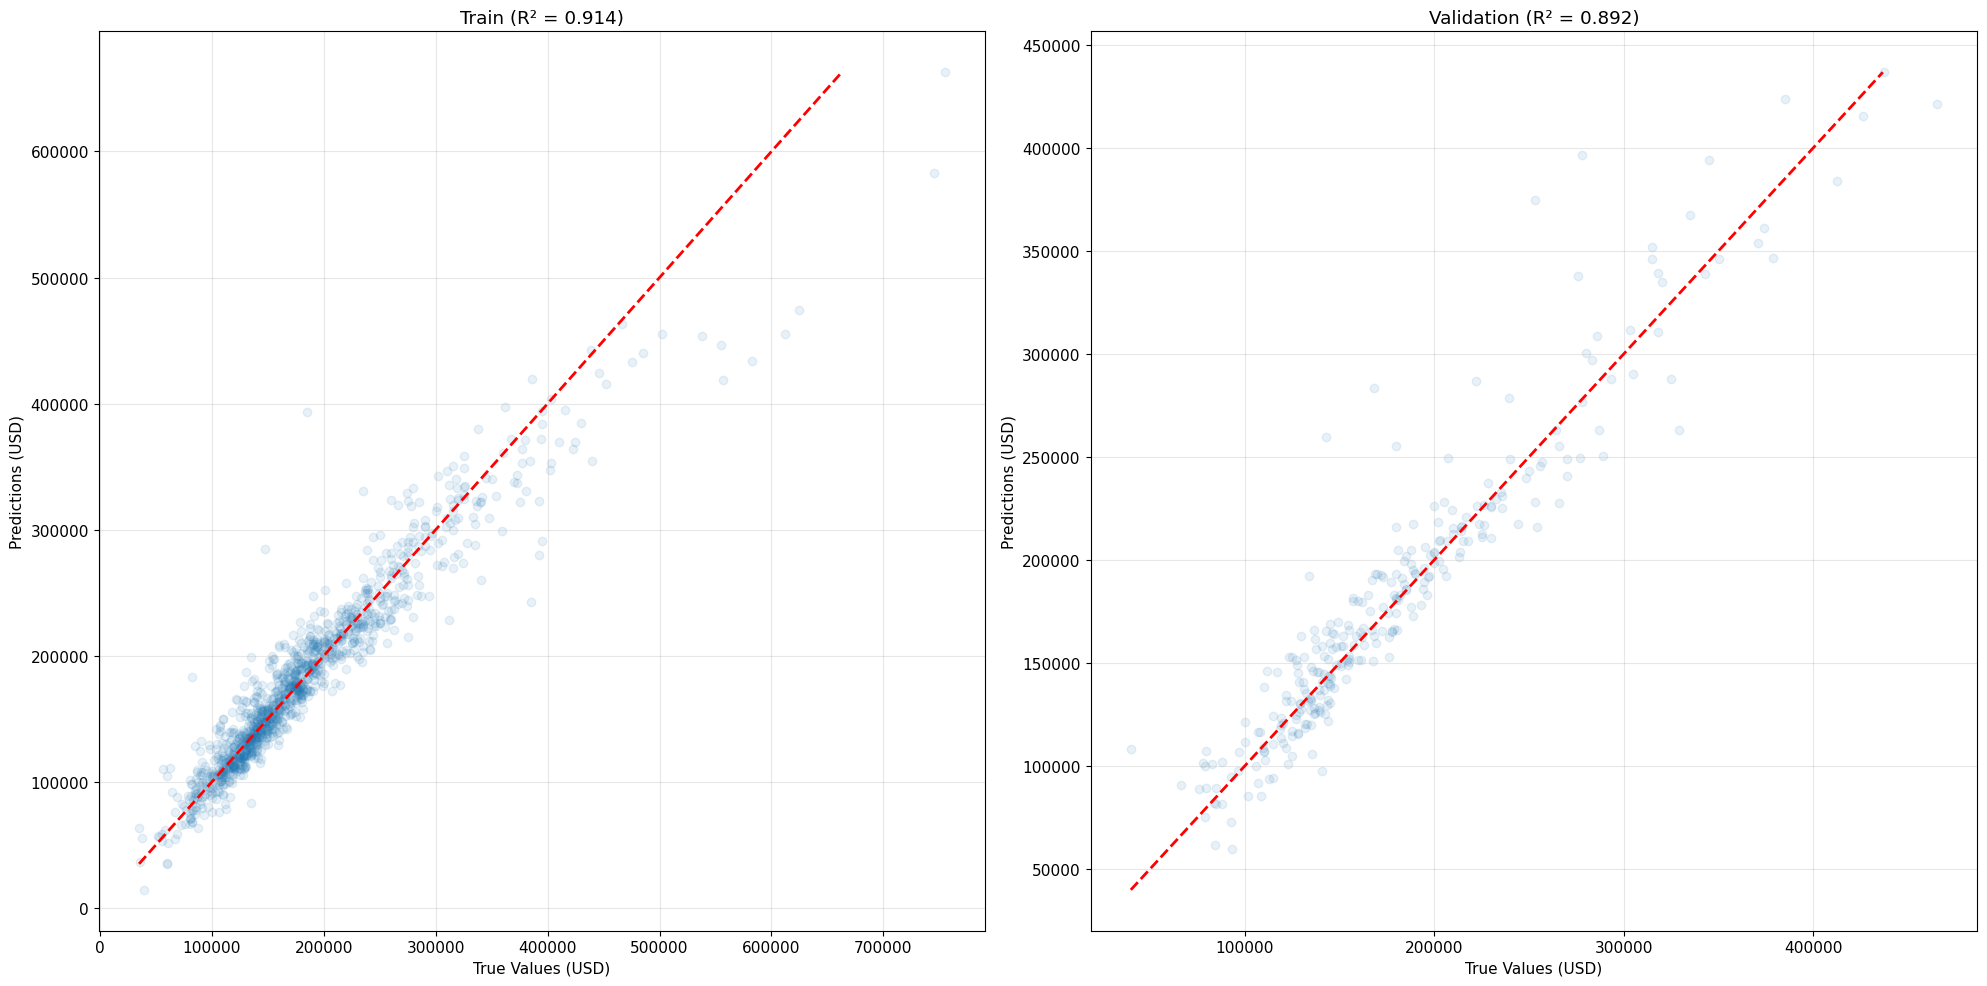

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
x_data = {'Train': y_train, 'Validation': y_valid}
y_data = {'Train': y_pred_train, 'Validation': y_pred_valid}

for ax, name in zip(axes, x_data):
    print(name, "True ", x_data[name].shape)
    print(name, "Pred ", y_data[name].shape)
    
    ax.scatter(x_data[name], y_data[name], alpha=0.1)
    ax.plot([x_data[name].min(), y_data[name].max()], 
            [x_data[name].min(), y_data[name].max()], 'r--', lw=2)
    ax.set_xlabel('True Values (USD)')
    ax.set_ylabel('Predictions (USD)')
    ax.set_title(f'{name} (R² = {sklearn.metrics.r2_score(x_data[name], y_data[name]):.3f})')
    ax.grid(True, alpha=0.3)
plt.tight_layout()

In [17]:
# запоминаем header!
header_one = np.copy(header_new)
np_data_concatenate_one = np.copy(np_data_concatenate)

In [18]:
#готовим тест
train_pd = pd.read_csv("test.csv") # Поменяли для удобства!!!
#test_pd = pd.read_csv("test.csv")

header_new = np.array([])

np_data_concatenate_numeric = np.zeros((train_pd.shape[0], 1))
np_data_concatenate_category = np.zeros((train_pd.shape[0], 1))

counter = 0
counter_2 = 0

for col, i in zip(train_pd.columns, range(np_to_do_column.shape[0])):
    print(f"i = {i}")
    if (np_to_do_column[i] == 0):
        # удаляем столбец. Он не нужен. А лучше сказать по другому - мы его не будет вставлять в новый numpy array
        print(f"Column name: {col}")
        print("Column not included \n")        
        continue

    elif (np_to_do_column[i] == 1):
        # копируем из pandas и вставляем в numpy array
        print(f"Column name: {col}")
        counter += 1 # для проверки
        
        np_add = train_pd[col].fillna(0).to_numpy()[:, None] # превращаем NaN в нули
        np_data_concatenate_numeric = np.concatenate((np_data_concatenate_numeric, np_add), axis = 1)
        nan_sum = np.isnan(np_add).sum()
        null_num = train_pd[col].isnull().sum()
        print(f"Null num: {null_num}") # для проверки
        print(f"NaN  num: {nan_sum} \n") # для проверки. Если показывает 0 - все верно

        # добавляем названия в header
        header_new = np.append(header_new, col)

    elif (np_to_do_column[i] == 2):
        print(f"Column name: {col}")

        null_num = train_pd[col].isnull().sum()
        print(f"Null num: {null_num}") # для проверки
        unique_data_column = train_pd[col].unique()
        print("Unique data types", unique_data_column.shape[0])
        
        train_pd[col] = train_pd[col].fillna("None") # убираем NULL
        null_num = train_pd[col].isnull().sum()
        print(f"Null num after changed: {null_num}") # для проверки 
        unique_data_column = train_pd[col].unique()
        print("Unique data types after changed", unique_data_column.shape[0]) # для проверки 

        counter_2 += unique_data_column.shape[0] # для проверки
        
        # добавляем в наш массив
        np_add = np.zeros((train_pd.shape[0], unique_data_column.shape[0])) # превращаем NaN в нули
        print("shape", np_add.shape)
        
        for i_new in range(train_pd.shape[0]):
            for j_new in range(unique_data_column.shape[0]):
                if (train_pd.loc[i_new, col] == unique_data_column[j_new]):
                    np_add[i_new, j_new] = 1 # этот элемент есть
                else:
                    continue # этого элемента нет - обнуляем

        np_data_concatenate_category = np.concatenate((np_data_concatenate_category, np_add), axis = 1)

        # добавляем названия в header
        for i in range(unique_data_column.shape[0]):
            head = str(unique_data_column[i]) + "_" + str(col)
            header_new = np.append(header_new, head)

        print("\n")

np_data_concatenate_numeric = np_data_concatenate_numeric[:, :-1] # убираем первый пустой столбец, который добавили в самом начале
np_data_concatenate_category = np_data_concatenate_category[:, :-1] 

i = 0
Column name: Id
Column not included 

i = 1
Column name: MSSubClass
Null num: 0
Unique data types 16
Null num after changed: 0
Unique data types after changed 16
shape (1459, 16)


i = 2
Column name: MSZoning
Null num: 4
Unique data types 6
Null num after changed: 0
Unique data types after changed 6
shape (1459, 6)


i = 3
Column name: LotFrontage
Null num: 227
NaN  num: 0 

i = 4
Column name: LotArea
Null num: 0
NaN  num: 0 

i = 5
Column name: Street
Null num: 0
Unique data types 2
Null num after changed: 0
Unique data types after changed 2
shape (1459, 2)


i = 6
Column name: Alley
Null num: 1352
Unique data types 3
Null num after changed: 0
Unique data types after changed 3
shape (1459, 3)


i = 7
Column name: LotShape
Null num: 0
Unique data types 4
Null num after changed: 0
Unique data types after changed 4
shape (1459, 4)


i = 8
Column name: LandContour
Null num: 0
Unique data types 4
Null num after changed: 0
Unique data types after changed 4
shape (1459, 4)


i = 9
Colu

In [19]:
np_data_concatenate = np.concatenate((np_data_concatenate_numeric, np_data_concatenate_category), axis = 1)
#np_data_concatenate = np.copy(np_data_concatenate_numeric)

print("Численные признаки      =", np_data_concatenate_numeric.shape[1], " == ", counter)
print("Категориальные признаки =", np_data_concatenate_category.shape[1], " == ", counter_2)
print("Размер данных матрицы   =", np_data_concatenate.shape)
print("Есть ли пропуски        =", np.isnan(np_data_concatenate).any())
print("Размер header           =", header_new.shape[0])

Численные признаки      = 34  ==  34
Категориальные признаки = 283  ==  283
Размер данных матрицы   = (1459, 317)
Есть ли пропуски        = False
Размер header           = 317


In [20]:
header_two = np.copy(header_new)
np_data_concatenate_two = np.copy(np_data_concatenate)

In [21]:
# Добавляем недостающие header
# Индексы элементов header_one, которых нет в header_two
mask = ~np.isin(header_one, header_two)
indices = np.where(mask)[0]
diff = np.setdiff1d(header_one, header_two)
print("Названия столбцов", diff)
print("Индексы этих столбцов", indices)
print("Размер массива разницы", indices.shape[0])

print("Размер train массива =", np_data_concatenate_one.shape)
print("Размер test  массива =", np_data_concatenate_two.shape)

new_np_data_concatenate = np.zeros((np_data_concatenate_two.shape[0], np_data_concatenate_one.shape[1]))

counter = 0
for i in range(np_data_concatenate_one.shape[1]):
    if (i in indices ):
        counter += 1
        continue
    else:
        new_np_data_concatenate[:, i] = np_data_concatenate_two[:, i-counter]

print("Размер final массива =", new_np_data_concatenate.shape)

Названия столбцов ['2.5Fin_HouseStyle' 'ClyTile_RoofMatl' 'Ex_GarageQual' 'Fa_PoolQC'
 'Floor_Heating' 'ImStucc_Exterior1st' 'Membran_RoofMatl' 'Metal_RoofMatl'
 'Mix_Electrical' 'NoSeWa_Utilities' 'None_Electrical' 'OthW_Heating'
 'Other_Exterior2nd' 'RRAe_Condition2' 'RRAn_Condition2' 'RRNn_Condition2'
 'Roll_RoofMatl' 'Stone_Exterior1st' 'TenC_MiscFeature']
Индексы этих столбцов [ 36  81  85  86  99 112 114 116 117 130 131 147 206 207 219 220 268 287
 298]
Размер массива разницы 19
Размер train массива = (1460, 328)
Размер test  массива = (1459, 317)
Размер final массива = (1459, 328)


In [22]:
# делаем нормировку
x_test = np.copy(new_np_data_concatenate) # берем новый
x_test = scaler.transform(x_test)

In [23]:
y_pred_test = lasso.predict(x_test)
print(y_pred_test.shape)

(1459,)


In [58]:
#RandomForest
y_pred_test_forest = random_search.predict(x_test)

In [59]:
# Загружаем тестовые данные (нужны только Id)
test_df = pd.read_csv('test.csv')
test_ids = test_df['Id']

# Создаём DataFrame для сабмита
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': y_pred_test_forest
})

# Проверяем формат
submission.head()

,Id,SalePrice
0,1461,119218.152383
1,1462,159597.664830
2,1463,170819.301408
3,1464,174206.269022
4,1465,187180.198613


In [60]:
# Сохраняем в CSV (без индекса!)
submission.to_csv('submission.csv', index=False)

In [25]:
# Анализ самых главных факторов
# Получаем веса признаков
coef_df = pd.DataFrame({
    'feature': header_one,  # ваши названия колонок
    'coef': lasso.coef_
})

# Топ-10 положительных (увеличивают цену)
print(coef_df.sort_values('coef', ascending=False).head(10))

# Топ-10 отрицательных (уменьшают цену)
print(coef_df.sort_values('coef', ascending=True).head(10))

# По модулю (сила влияния)
coef_df['abs_coef'] = abs(coef_df['coef'])
print(coef_df.sort_values('abs_coef', ascending=False).head(10))

                 feature          coef
15           RL_MSZoning  23563.996571
3          50_MSSubClass  14816.820152
199           BsmtFinSF2   6835.126792
11        160_MSSubClass   6546.150757
5          45_MSSubClass   6210.184266
8          30_MSSubClass   6198.565630
247       Fa_FireplaceQu   5694.659631
81       RRNn_Condition2   5348.897962
120  Wd Sdng_Exterior1st   4442.509826
96     SFoyer_HouseStyle   3901.699773
                  feature          coef
146     Stone_Exterior2nd -13860.776826
116         Roll_RoofMatl  -6116.418834
183     None_BsmtExposure  -2216.292242
207         Floor_Heating  -1826.370857
246        Gd_FireplaceQu  -1484.646589
14          40_MSSubClass   -968.386505
51    NWAmes_Neighborhood   -820.912777
52   OldTown_Neighborhood   -590.414708
85        RRAn_Condition2   -529.573186
21                LotArea   -354.361328
               feature          coef      abs_coef
15         RL_MSZoning  23563.996571  23563.996571
3        50_MSSubClass  14816